In [73]:
#Cell 1: Libraries import
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [74]:
#Cell 2: Paths and settings
train_path = "dataset/train"
test_path = "dataset/test"

img_size = 128
batch_size = 32

In [75]:
#Cell 3: Image preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [76]:
#Cell 4: Dataset load
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical"
)

Found 677 images belonging to 5 classes.
Found 165 images belonging to 5 classes.


In [77]:
#Cell 5: Class names check
print(train_data.class_indices)

{'apple': 0, 'banana': 1, 'potato': 2, 'tomato': 3, 'unknown': 4}


In [78]:
#Cell 6: CNN Model
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(img_size, img_size, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(5, activation="softmax")
])

In [79]:
#Cell 7: Compile model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [80]:
#Cell 8: Model summary
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)            │ (None, 126, 126, 32)  │          896 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_15              │ (None, 63, 63, 32)    │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_16 (Conv2D)            │ (None, 61, 61, 64)    │       18,496 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_16              │ (None, 30, 30, 64)    │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2d_17 (Conv2D)            │ (None, 28, 28, 128)   │       73,856 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ max_pooling2d_17              │ (None, 14, 14, 128)   │            0 │
│ (MaxPooling2D)                │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ flatten_5 (Flatten)           │ (None, 25088)         │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_10 (Dense)              │ (None, 128)           │    3,211,392 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout_5 (Dropout)           │ (None, 128)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_11 (Dense)              │ (None, 5)             │          645 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
#Cell 9: Train model
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.4801 - loss: 1.4949 - val_accuracy: 0.5030 - val_loss: 1.3137
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.6470 - loss: 0.9621 - val_accuracy: 0.5818 - val_loss: 1.2351
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.7223 - loss: 0.7397 - val_accuracy: 0.6303 - val_loss: 1.2587
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.7770 - loss: 0.6326 - val_accuracy: 0.6303 - val_loss: 1.1773
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.7932 - loss: 0.5788 - val_accuracy: 0.6121 - val_loss: 1.3897
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.8552 - loss: 0.4534 - val_accuracy: 0.6788 - val_loss: 1.2719
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8789 - loss: 0.3488 - val_accuracy: 0.7515 - val_loss: 1.1456
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9055 - loss: 0.3420 - val_accuracy: 0.7212 - val_loss:

In [82]:
#Cell 10: Save model
model.save("model/freshscan_model.h5")
print("Model saved successfully!")

Model saved successfully!


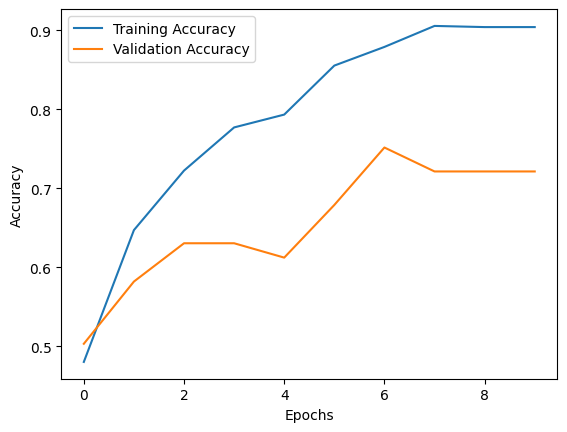

In [83]:
#Cell 11: Accuracy graph
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()